# Compare Event Selection for Detector Variation Samples

- Note: This **needs** EAF resources, don't run on gpvms

In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial


# local imports
import sys
# sys.path.append('../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
import matplotlib as mpl
plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

mc_n_split: 1
mc_tot_pot: 1.518e+19
Integrated flux: 2.452e+11
# of targets:  1.3251484770937053e+30
xsec unit:  3.0775821542623837e-42


In [8]:
save_result = False
save_fig = save_result

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "systematics-detvar-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

In [9]:
data = False
if data:
    data_file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
    data_file = path.join(data_file_dir, "data", "BNB", "mup.df")
    data_split_df = pd.read_hdf(data_file, key="split")
    data_n_split = get_n_split(data_file)
    print("data_n_split: %d" %(data_n_split))
    print_keys(data_file)
    data_keys2load = ['evt', 'hdr', 'bnbpot']
    data_dfs = load_dfs(data_file, data_keys2load, n_max_concat=5)
    data_evt_df = data_dfs['evt']
    data_hdr_df = data_dfs['hdr']
    data_bnbpot_df = data_dfs['bnbpot']
    data_tot_pot = data_hdr_df['pot'].sum()

In [10]:
# variations
# this_variation = "WireMod"
# syst_keys = ["CV", "WireMod_XThetaXW", "WireMod_YZ"]

this_variation = "SCE"
syst_keys = ["CV", "0xSCE", "2xSCE"]

# Create a specialized version of your function for this specific analysis
labels    = ["CV", r"X-$\theta_{xw}$", r"Y-Z"]
colors    = ["black", "C0", "C1"]

detvar_plotter = partial(
    variation_hists,
    var_colors=colors,
    var_labels=labels,
    approval="internal"
)

In [11]:
# # file_dir = "/exp/sbnd/data/users/munjung/xsec/2025spring_v10_06_00_10"
# file_dir = "/scratch/7DayLifetime/munjung/xsec/detvars"
# syst_dfs = {}
# for sidx, syst_key in enumerate(syst_keys):
#     filename = "SystVar_{}_wtrks.df".format(syst_key)
#     mc_file = path.join(file_dir, filename)
#     mc_split_df = pd.read_hdf(mc_file, key="split")
#     mc_n_split = get_n_split(mc_file)
#     print("mc_n_split: %d" %(mc_n_split))
#     print_keys(mc_file)

#     n_max_concat = 100
#     mc_keys2load = ['hdr', 'evt', 'trk'] 
#     mc_dfs = load_dfs(mc_file, mc_keys2load, n_max_concat=n_max_concat)
#     mc_hdr_df = mc_dfs['hdr']
#     # print("total pot: %.3e" %(mc_hdr_df["pot"].sum()))
#     mc_evt_df = mc_dfs['evt']
#     mc_trk_df = mc_dfs['trk']
#     mc_trk_df = mc_trk_df[mc_trk_df.pfp.trk.producer != 4294967295]
#     mask = (mc_trk_df.pfp.trk.len > 0) &\
#          (mc_trk_df.pfp.pfochar.vtxdist < 100) #&\
#     mc_trk_df = mc_trk_df[mask]

#     nlevels = len(mc_evt_df.columns.levels)
#     index_names = mc_evt_df.index.names
#     mc_hdr_df.columns = pd.MultiIndex.from_tuples([tuple([str(c)] +[""] * (nlevels-1)) for c in mc_hdr_df.columns]) 
#     mc_evt_df = multicol_merge(mc_evt_df.reset_index(), 
#                                mc_hdr_df.reset_index(),
#                                left_on=["__ntuple", "entry"],
#                                right_on=["__ntuple", "entry"],
#                                how="left"
#                                ) 
#     mc_evt_df = mc_evt_df.set_index(index_names, verify_integrity=True) 

#     # need to match the nu_Es across files
#     mc_evt_df["nu_E"] = mc_evt_df.mc.E

#     syst_dfs[syst_key] = mc_evt_df
#     syst_dfs[syst_key+"_trk"] = mc_trk_df

# del mc_hdr_df
# del mc_evt_df

# # match common events
# for k in syst_keys:
#     syst_dfs[k] = syst_dfs[k].reset_index().set_index(["run","subrun","evt","nu_E"])
#     # print(len(syst_dfs[k].index))

# for kidx, k in enumerate(syst_keys):
#     idxs = syst_dfs[k].index
#     if kidx == 0:
#         common_idxs = idxs
#     else:
#         common_idxs = common_idxs.intersection(idxs)
# # print(len(common_idxs))

# last_level_values = common_idxs.get_level_values("nu_E")
# mask_notnan = ~pd.isna(last_level_values)
# common_idx_notnan = common_idxs[mask_notnan]

# for k in syst_keys:
#     common_nu_df = syst_dfs[k].loc[common_idx_notnan]
#     common_nu_df = common_nu_df.reset_index().set_index(["run","subrun","evt","__ntuple"])
#     common_nu_idx = common_nu_df.index
#     del common_nu_df

#     common_nu_idx = common_nu_idx.drop_duplicates()
#     common_df = syst_dfs[k].reset_index().set_index(["run","subrun","evt","__ntuple"])
#     common_df = common_df.loc[common_nu_idx]

#     this_pot = common_df[common_df["first_in_subrun"] == 1]["pot"].sum()
#     # print(this_pot)
#     if "CV" in k: 
#         cv_pot = this_pot
#         common_df["pot_weight"] = np.ones(len(common_df))
#     else:
#         pot_scale = cv_pot / this_pot
#         print(pot_scale)
#         common_df["pot_weight"] = np.ones(len(common_df)) * pot_scale

#     syst_dfs[k] = common_df

# # total POT (not used for syst sample comparison)
# # tot_pot = syst_dfs['CV'].groupby(level=[0,1]).nth(0)['pot'].sum()
# tot_pot = syst_dfs['CV'][syst_dfs['CV']['first_in_subrun'] == 1]["pot"].sum()
# print("mc_tot_pot: %.3e" %(tot_pot))
# pot_str = get_pot_str(tot_pot)


# for syst_key in syst_keys:
#     syst_dfs[syst_key] = syst_dfs[syst_key].reset_index().set_index(list(syst_dfs[f'{syst_key}_trk'].index.names)[:-1])
#     syst_dfs[syst_key+"_trk"] = get_valid_trks(syst_dfs[syst_key+"_trk"])
#     syst_dfs[syst_key+"_trk"] = match_trkdf_to_slcdf(syst_dfs[syst_key+"_trk"], syst_dfs[syst_key])

# # save matched dfs 
# save_filename = path.join(file_dir, "BNB_cosmics-matched-{}.h5".format(this_variation))
# with pd.HDFStore(save_filename, "a") as store:
#     for syst_key in syst_dfs.keys():
#         print(syst_key)
#         store.put(syst_key, syst_dfs[syst_key])
# print("save matched dfs in ", save_filename)

In [12]:
# load matched dfs 
syst_dfs = {}
scratch_file_dir = "/scratch/7DayLifetime/munjung/xsec/detvars"
save_filename = path.join(scratch_file_dir, "BNB_cosmics-matched-{}.h5".format(this_variation))
with pd.HDFStore(save_filename, "r") as store:
    for syst_key in syst_keys:
        syst_dfs[syst_key] = store.get(syst_key)
        syst_dfs[syst_key+"_trk"] = store.get(syst_key+"_trk")

In [13]:
if data:
    pot_str = get_pot_str(data_tot_pot)
else:
    data_tot_pot = 5.950e18
    pot_str = get_pot_str(data_tot_pot)
pot_label = f"Events / Bin (POT={pot_str})"

mc_n_split: 1
mc_tot_pot: 1.518e+19
Integrated flux: 2.452e+11
# of targets:  1.3251484770937053e+30
xsec unit:  3.0775821542623837e-42


In [14]:
# ==== events selection cuts ====
# slice cuts
nu_score_th   = 0.45
save_ntrks    = 2
# track quality cuts
trackscore_th = 0.5
vtxdist_th    = 1.2
# pid cuts
mu_chi2mu_th  = 30
mu_chi2p_th   = 100
mu_len_th     = 50
qual_th       = 0.2
p_chi2p_th    = 90
p_len_th      = 0
# kinematic cuts
mu_Plo_th     = 0.22
mu_Phi_th     = 1
p_Plo_th      = 0.3
p_Phi_th      = 1

In [15]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_clear_cosmic(syst_dfs[syst_key])
    syst_dfs[syst_key] = cut_vertex_in_fv(syst_dfs[syst_key])

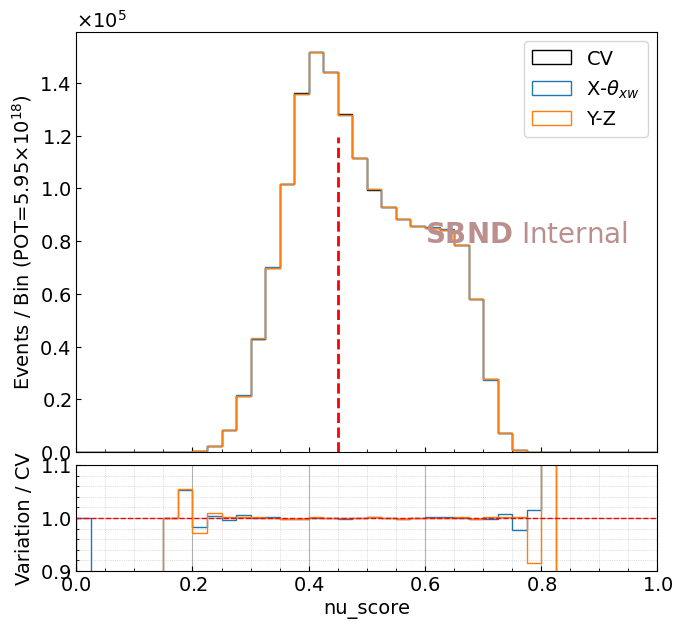

In [16]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]
var_name = ("slc","nu_score")
bins = np.linspace(0., 1., 41)
plot_labels = ["nu_score", pot_label, ""]
save_name = save_fig_dir + "/{}.png".format("nu_score")
n = detvar_plotter(evtdfs, 
                   var_name=var_name, 
                   bins=bins,
                   plot_labels=plot_labels,
                   vline=[nu_score_th],
                   save_fig=save_fig, save_name=save_name)

In [17]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_nu_score(syst_dfs[syst_key], nu_score_th)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9998881461275873
0.9998047833358834


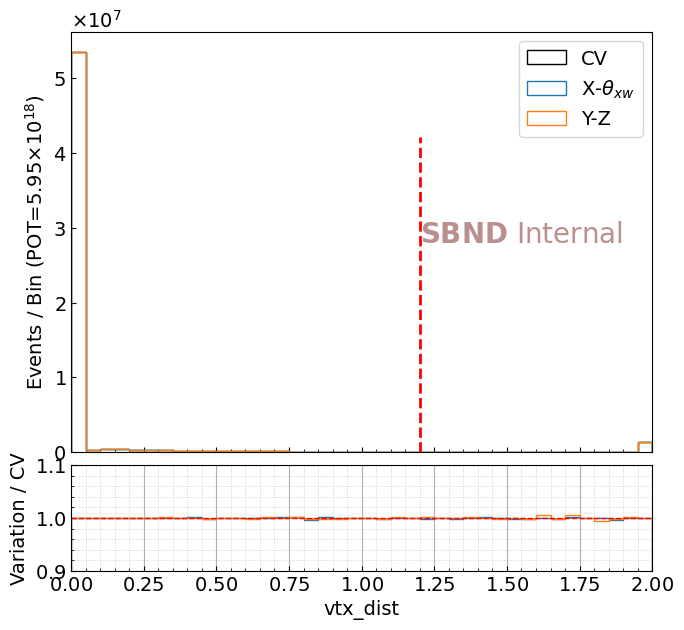

In [18]:
evtdfs = [syst_dfs[syst_key+"_trk"] for syst_key in syst_keys]
var_name = ("pfp","pfochar","vtxdist")
bins = np.linspace(0, 2, 41)
plot_labels = ["vtx_dist", pot_label, ""]
save_name = save_fig_dir + "/{}.png".format("vtx_dist")
n = detvar_plotter(evtdfs, 
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[vtxdist_th],
                    save_fig=save_fig, save_name=save_name)

In [19]:
for k in syst_keys:
    syst_dfs[k] = get_trk_info(syst_dfs[k], syst_dfs[f'{k}_trk'], save_ntrks)
    del syst_dfs[f'{k}_trk']
# del mc_trk_df

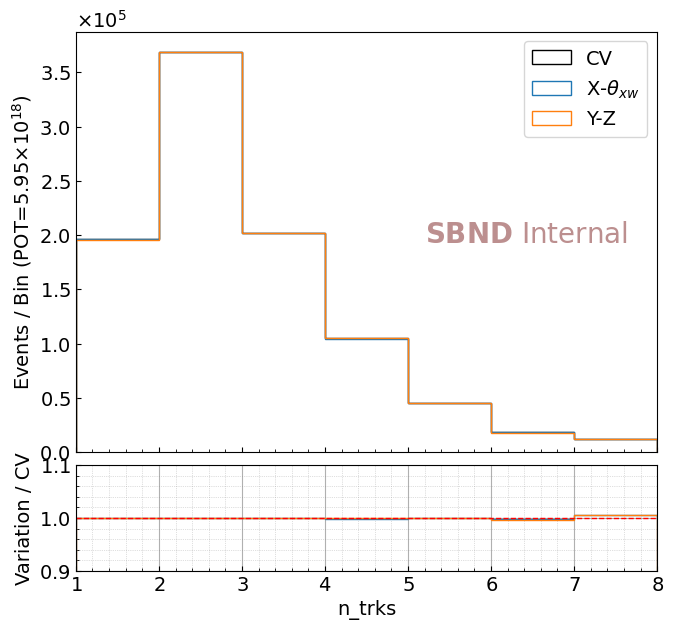

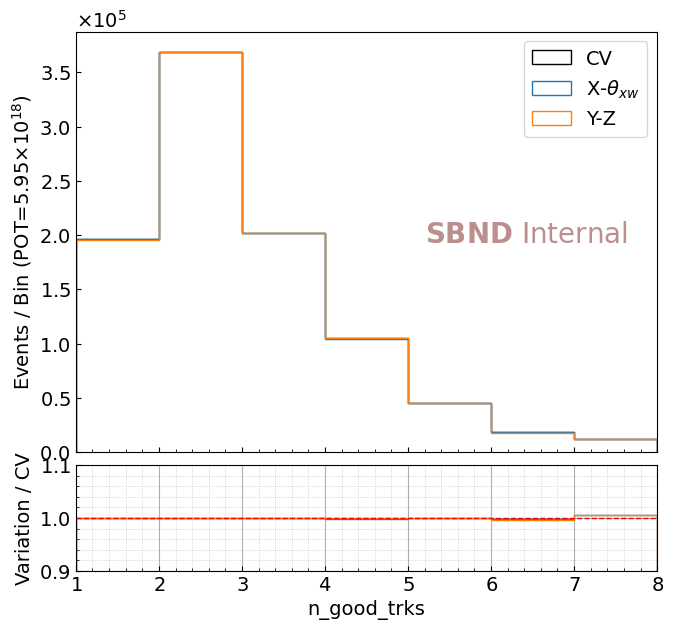

In [20]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_keys]

var_name = "n_trks"
bins = np.linspace(1, 8, 8)
plot_labels = ["n_trks", pot_label, ""]
save_name = save_fig_dir + "/{}.png".format("n_trks")
n = detvar_plotter(evtdfs, 
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    save_fig=save_fig, save_name=save_name)

var_name = "n_good_trks"
bins = np.linspace(1, 8, 8)
plot_labels = ["n_good_trks", pot_label, ""]
save_name = save_fig_dir + "/{}.png".format("n_good_trks")
n = detvar_plotter(evtdfs, 
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    save_fig=save_fig, save_name=save_name)

In [21]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_2prong_contained(syst_dfs[syst_key])

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9998307582951513
0.9997538302474929


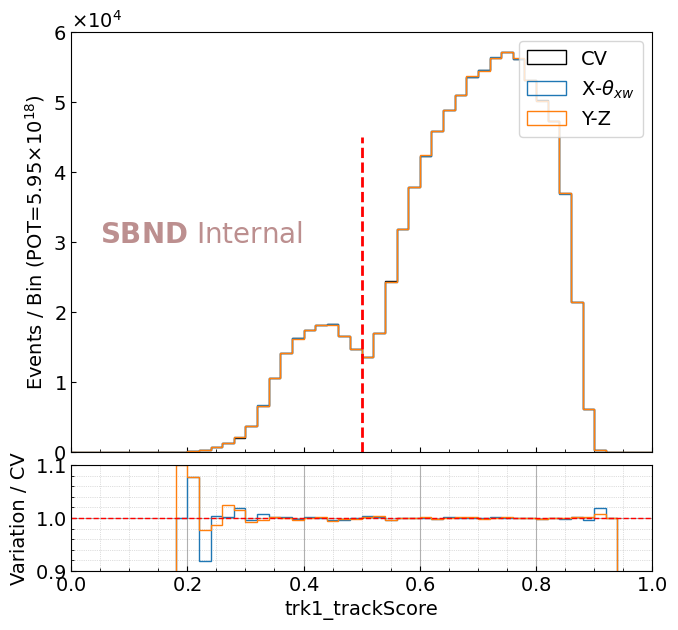

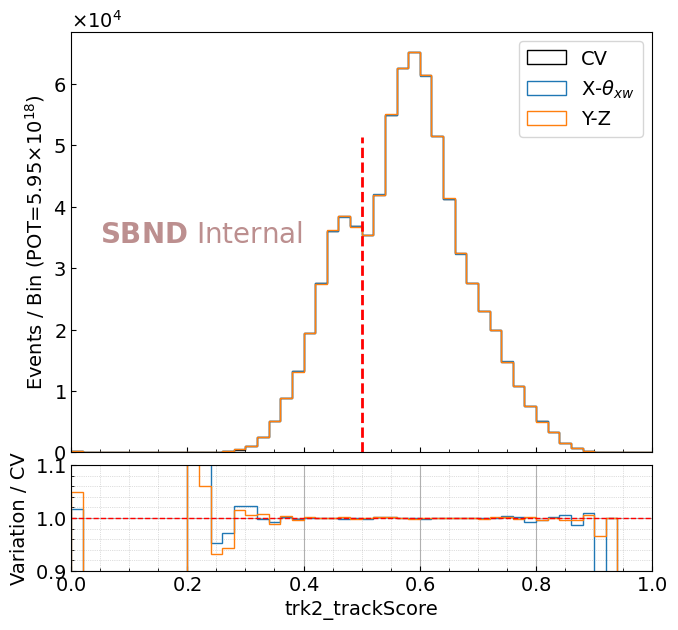

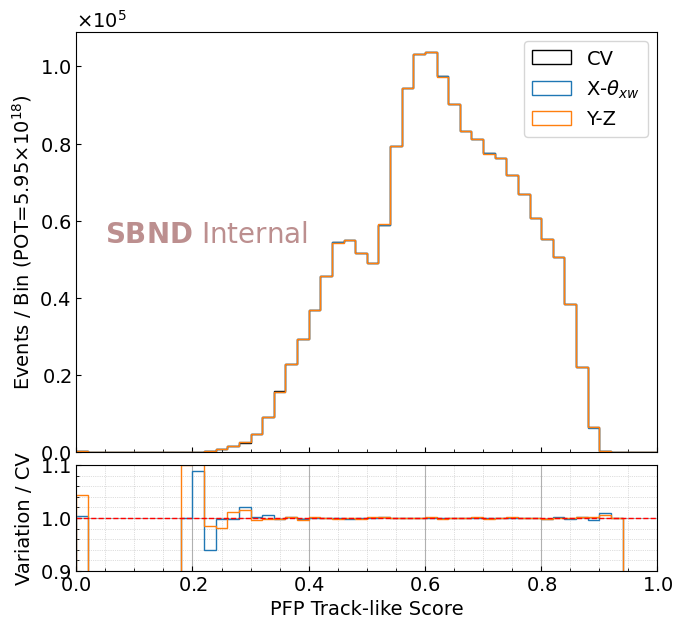

In [22]:
evtdf = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trackScore")
    bins = np.linspace(0, 1, 51)
    save_tag = "trk{}_trackScore".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + "/{}.png".format(save_tag)
    n = detvar_plotter(evtdfs, 
                        var_name=var_name,
                        bins=bins,
                        plot_labels=plot_labels,
                        vline=[trackscore_th],
                        save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = ["PFP Track-like Score", pot_label, ""]
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[mu_chi2mu_th],
                    save_fig=save_fig, save_name=save_name)

In [23]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_2prong_trackscore(syst_dfs[syst_key], trackscore_th)
    syst_dfs[syst_key] = cut_2prong_vtxdist(syst_dfs[syst_key], vtxdist_th)
    
for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9998535066837575
0.9997875846914485


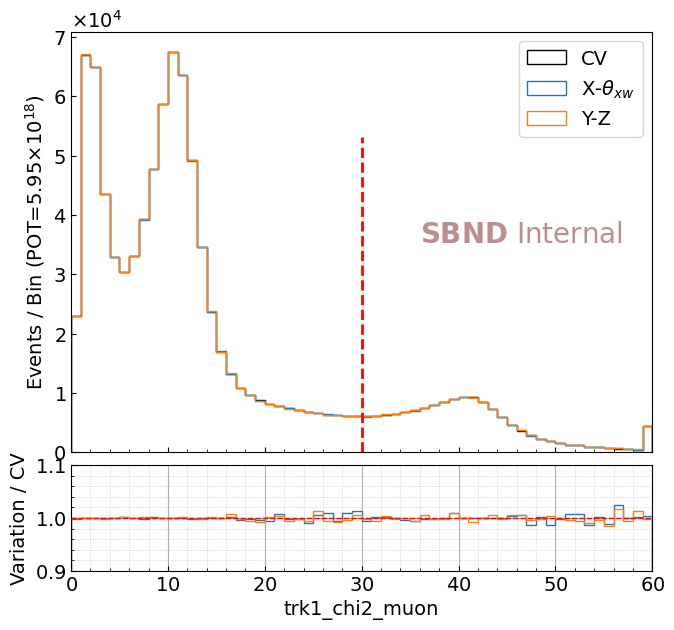

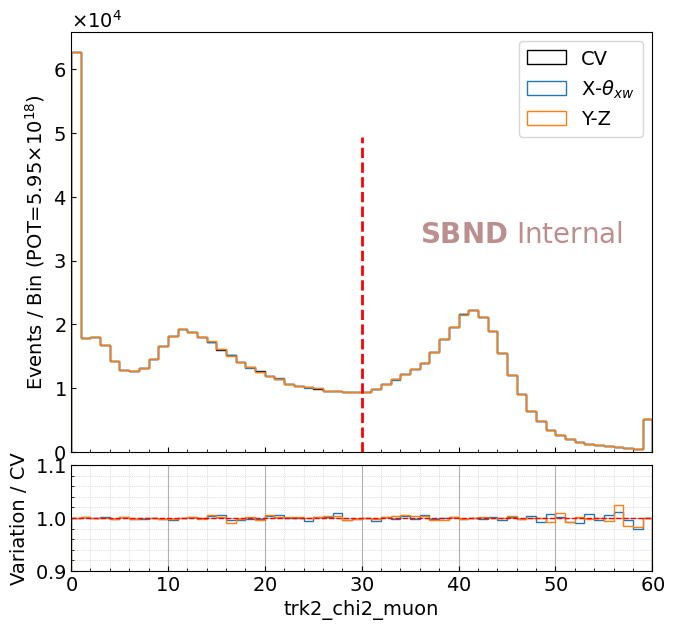

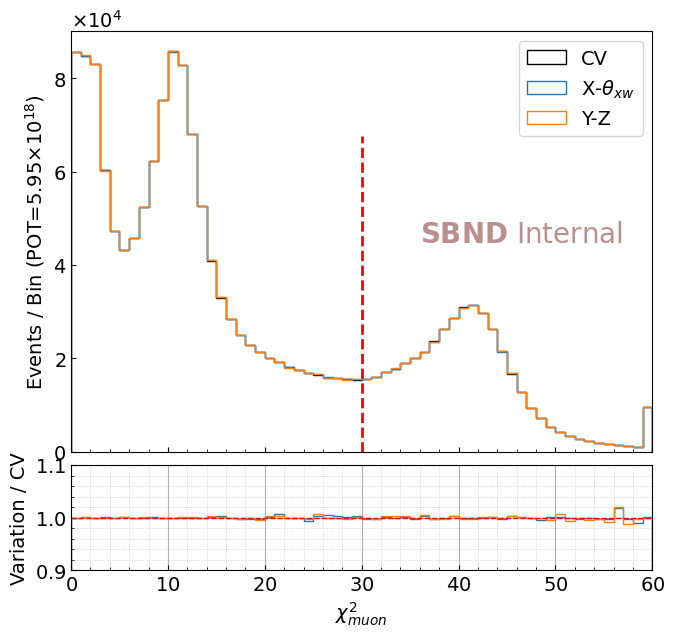

In [25]:
evtdf = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "chi2pid", "avg", "chi2_muon")
    bins = np.linspace(0, 60, 61)
    save_tag = "trk{}_chi2_muon".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + "/{}.png".format(save_tag)
    n = detvar_plotter(evtdfs, 
                       var_name=var_name,
                       bins=bins,
                       plot_labels=plot_labels,
                       vline=[mu_chi2mu_th],
                       save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = [r"$\chi^2_{muon}$", pot_label, ""]
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[mu_chi2mu_th],
                    save_fig=save_fig, save_name=save_name)

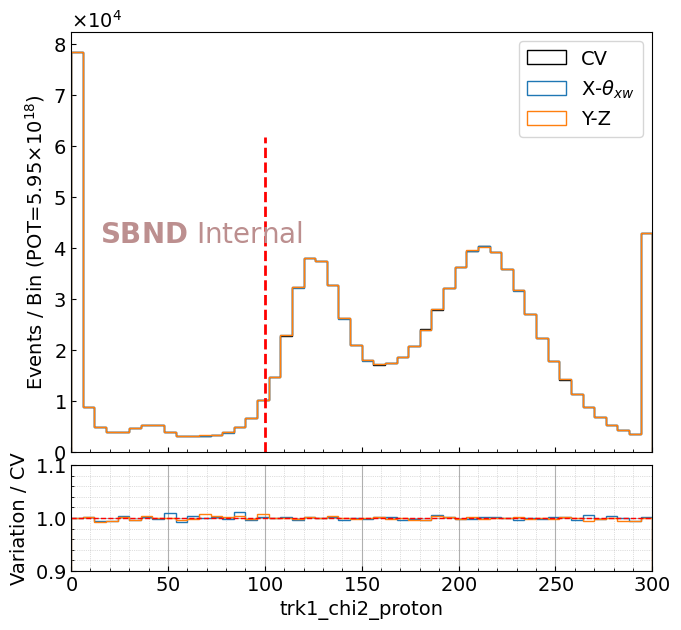

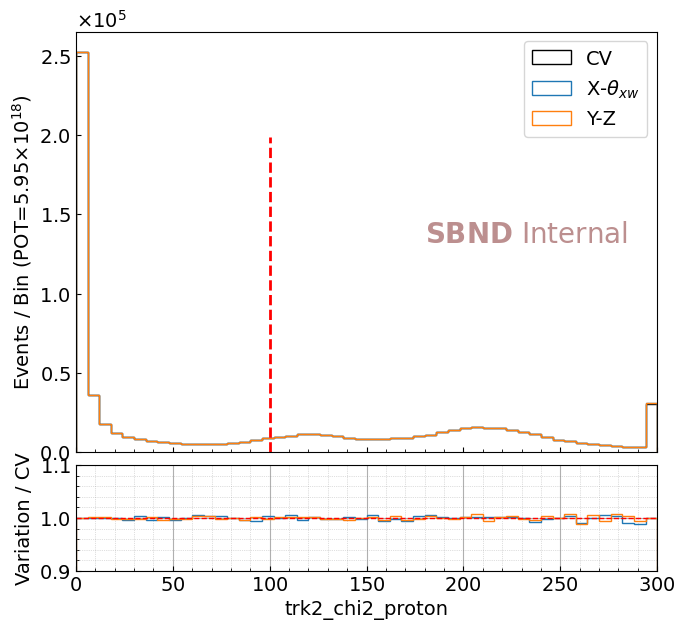

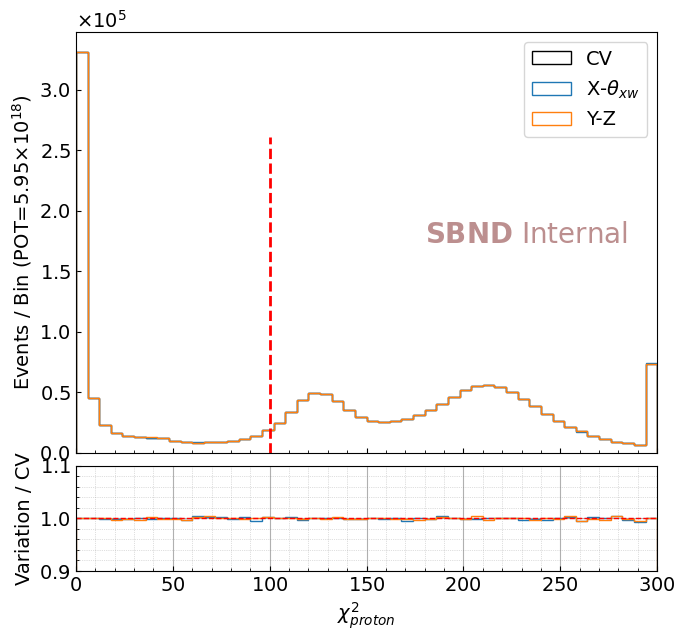

In [26]:
evtdf = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "chi2pid", "I2", "chi2_proton")
    bins = np.linspace(0, 300, 51)
    save_tag = "trk{}_chi2_proton".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + "/{}.png".format(save_tag)
    n = detvar_plotter(evtdfs, 
                        var_name=var_name,
                        bins=bins,
                        plot_labels=plot_labels,
                        vline=[mu_chi2p_th],
                        save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = [r"$\chi^2_{proton}$", pot_label, ""]
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[mu_chi2p_th],
                    save_fig=save_fig, save_name=save_name)

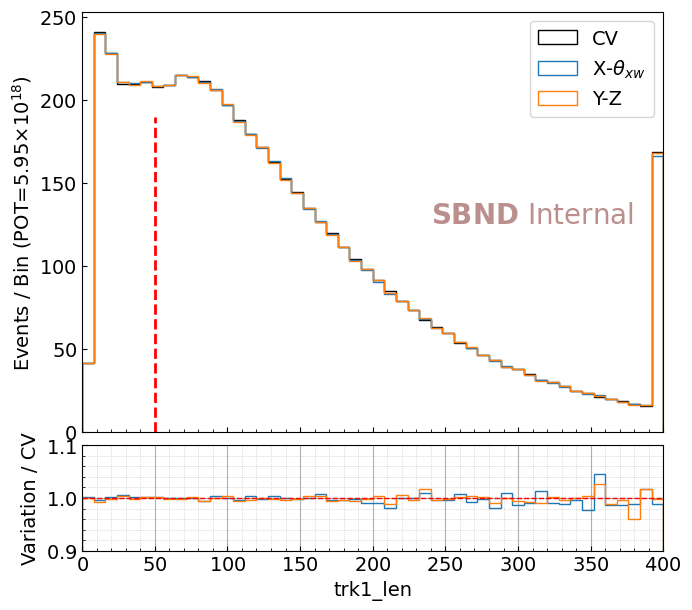

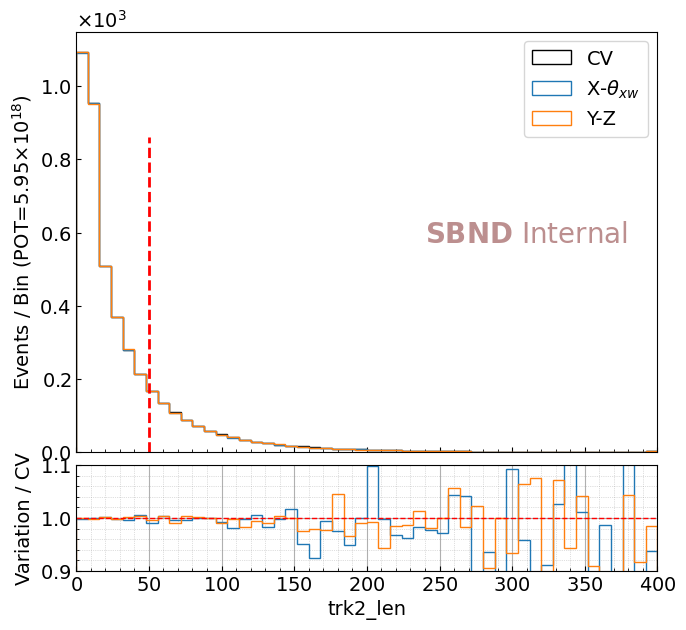

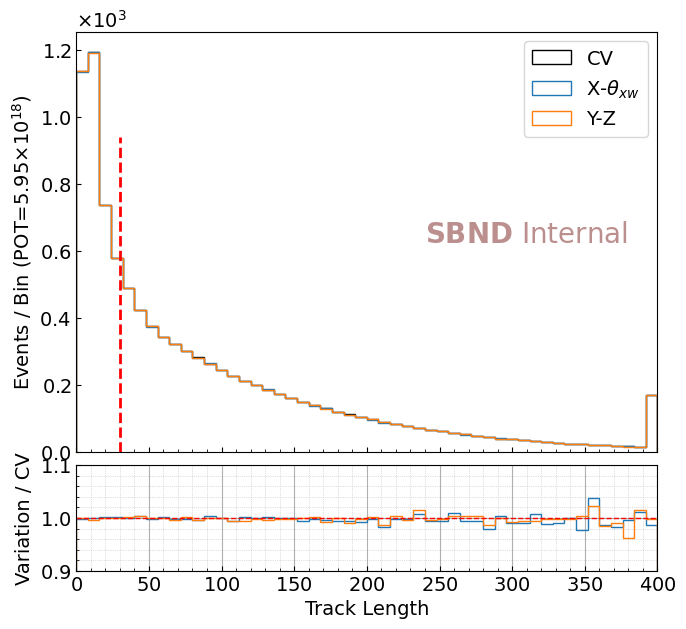

In [ ]:
evtdf = [syst_dfs[syst_key] for syst_key in syst_keys]
n_list = []
for trk_id in range(1, 3):
    var_name = ("trk{}".format(trk_id), "pfp", "trk", "len")
    bins = np.linspace(0, 400, 51)
    save_tag = "trk{}_len".format(trk_id)
    plot_labels = [save_tag, pot_label, ""]
    save_name = save_fig_dir + "/{}.png".format(save_tag)
    n = detvar_plotter(evtdfs, 
                        var_name=var_name,
                        bins=bins,
                        plot_labels=plot_labels,
                        vline=[mu_len_th],
                        save_fig=save_fig, save_name=save_name)
    n_list.append(n)

plot_labels = ["Track Length", pot_label, ""]
_ = detvar_plotter(evtdfs=None, 
                    nevts_list=np.sum(n_list, axis=0),
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    vline=[mu_chi2mu_th],
                    save_fig=save_fig, save_name=save_name)

In [ ]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = get_mu_p_candidate(syst_dfs[syst_key], 
                            mu_chi2mu_th=mu_chi2mu_th, mu_chi2p_th=mu_chi2p_th, mu_len_th=mu_len_th, qual_th=qual_th,
                            p_chi2mu_th=-1, p_chi2p_th=p_chi2p_th, p_len_th=p_len_th)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9945720101417705
0.9984823054672713


In [ ]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_has_mu(syst_dfs[syst_key]) 
    syst_dfs[syst_key] = cut_mu_kinematics(syst_dfs[syst_key], mu_Plo_th=mu_Plo_th, mu_Phi_th=mu_Phi_th)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9890579996611509
0.9932371378550856


In [ ]:
for syst_key in syst_keys:
    syst_dfs[syst_key] = cut_has_p(syst_dfs[syst_key]) 
    syst_dfs[syst_key] = cut_p_kinematics(syst_dfs[syst_key], p_Plo_th=p_Plo_th, p_Phi_th=p_Phi_th)

for syst_key in syst_keys:
    if "CV" not in syst_key:
        print(len(syst_dfs[syst_key]) / len(syst_dfs['CV']))

0.9842194092827005
1.0029324894514768


In [ ]:
detvar_weights = {}

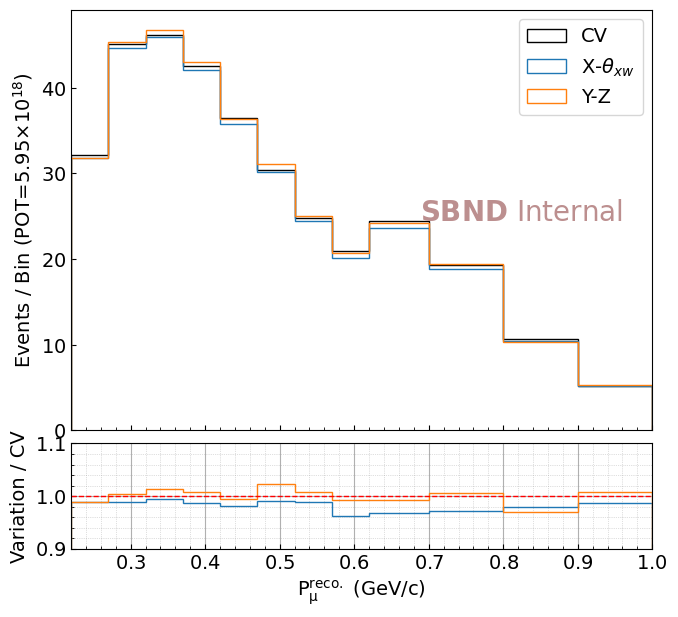

[338.36286888 333.02330293 339.35511442]


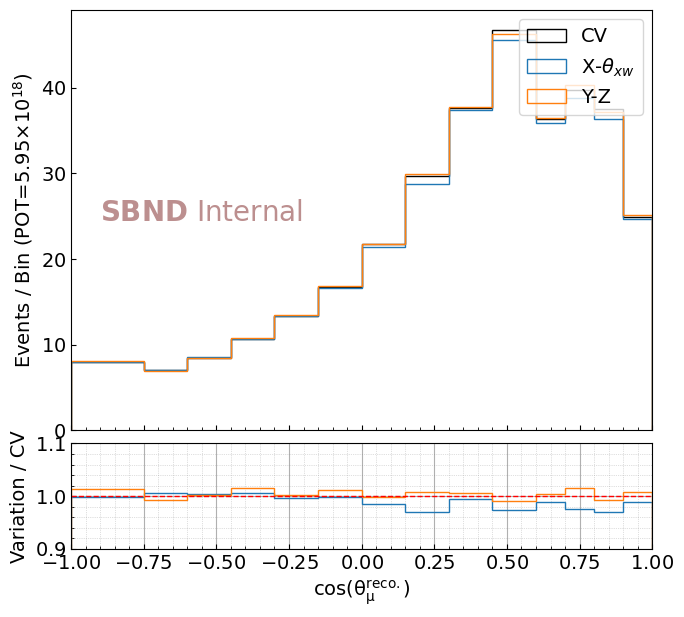

[338.36286888 333.02330293 339.35511442]


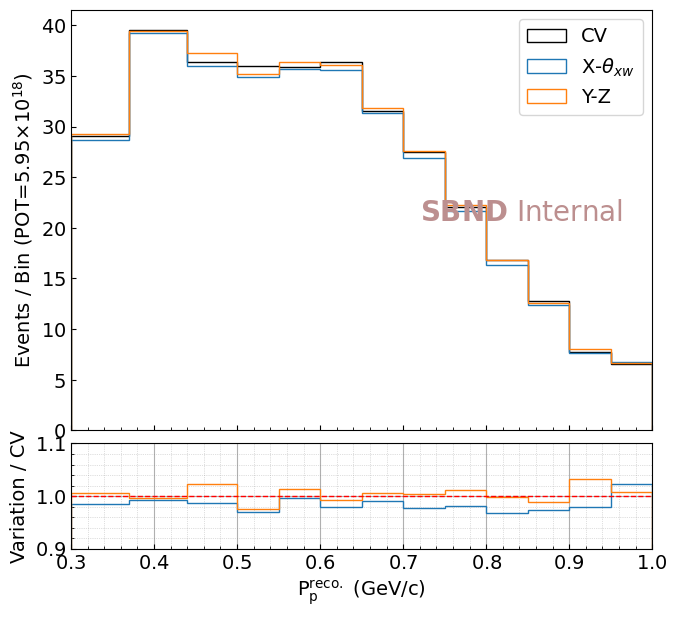

[338.36286888 333.02330293 339.35511442]


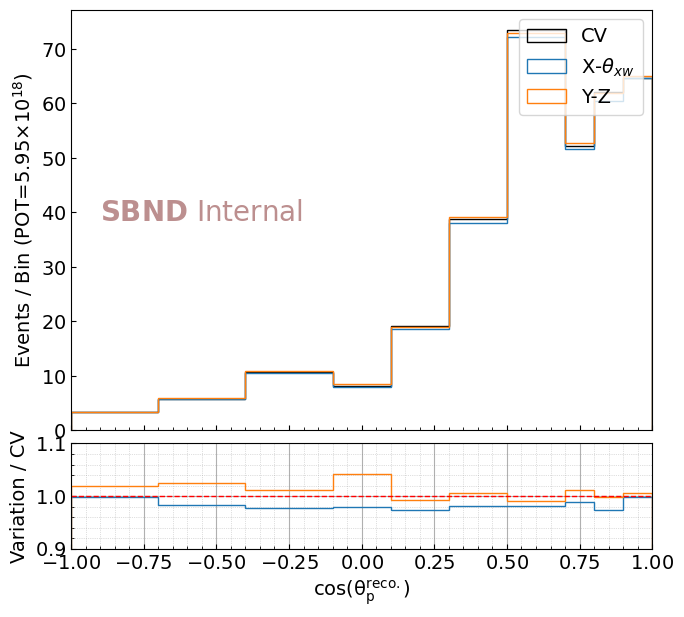

[338.36286888 333.02330293 339.35511442]


In [ ]:
for var_config in [VariableConfig.muon_momentum(), VariableConfig.muon_direction(), VariableConfig.proton_momentum(), VariableConfig.proton_direction()]:
        evtdfs = [syst_dfs[syst_key] for syst_key in syst_dfs.keys()]
        var_name = var_config.var_evt_reco_col
        bins = var_config.bins
        plot_labels = [var_config.var_labels[1], pot_label, ""]
        save_name = save_fig_dir + "/{}.png".format(var_config.var_save_name)
        n = detvar_plotter(evtdfs, 
                            var_name=var_name,
                            bins=bins,
                            plot_labels=plot_labels,
                            vline=[],
                            save_fig=save_fig, save_name=save_name)
        print(np.sum(n, axis=1))
        detvar_weights[var_config.var_save_name] = [n[i]/n[0] for i in range(len(syst_dfs.keys()))]

In [ ]:
from pyanalib.variable_calculator import get_cc1p0pi_tki

tki_var_names = ["del_alpha", "del_phi", "del_Tp", "del_p", "del_Tp_x", "del_Tp_y"]
for syst_key in syst_dfs.keys():
    slc_mudf = syst_dfs[syst_key].mu.pfp.trk
    slc_pdf = syst_dfs[syst_key].p.pfp.trk
    slc_P_mu_col = pad_column_name(("P", "p_muon"), slc_mudf)
    slc_P_p_col = pad_column_name(("P", "p_proton"), slc_pdf)
    tki_reco = get_cc1p0pi_tki(slc_mudf, slc_pdf, slc_P_mu_col, slc_P_p_col)
    for var_name in tki_var_names:
        syst_dfs[syst_key] = multicol_add(syst_dfs[syst_key], tki_reco[var_name].rename(var_name))

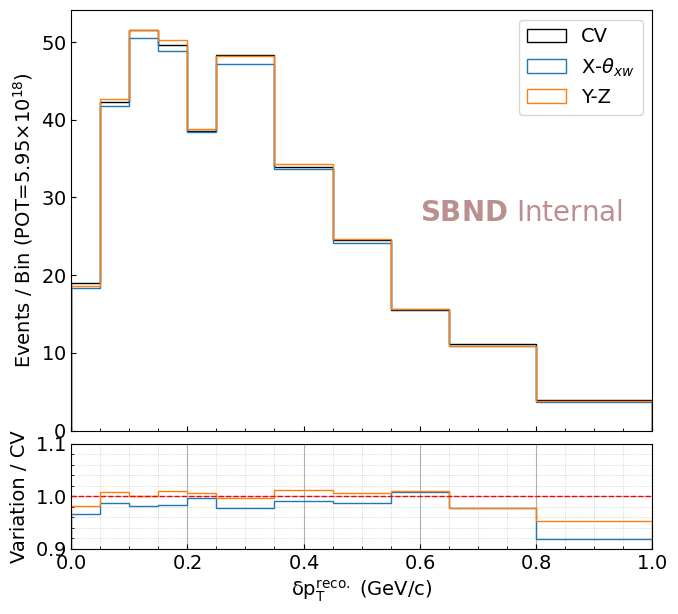

[338.36286888 333.02330293 339.35511442]


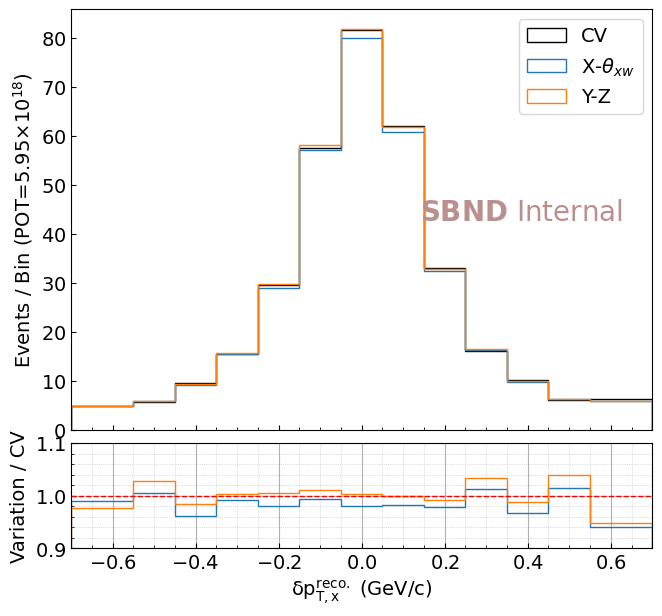

[338.36286888 333.02330293 339.35511442]


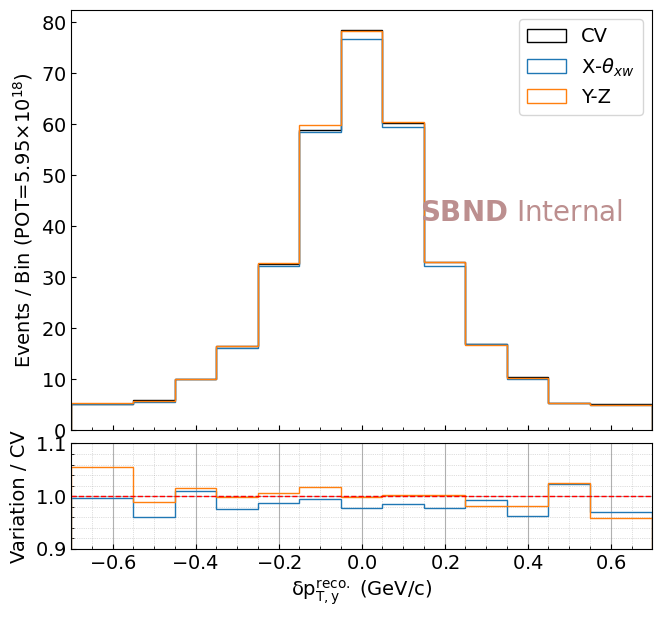

[338.36286888 333.02330293 339.35511442]


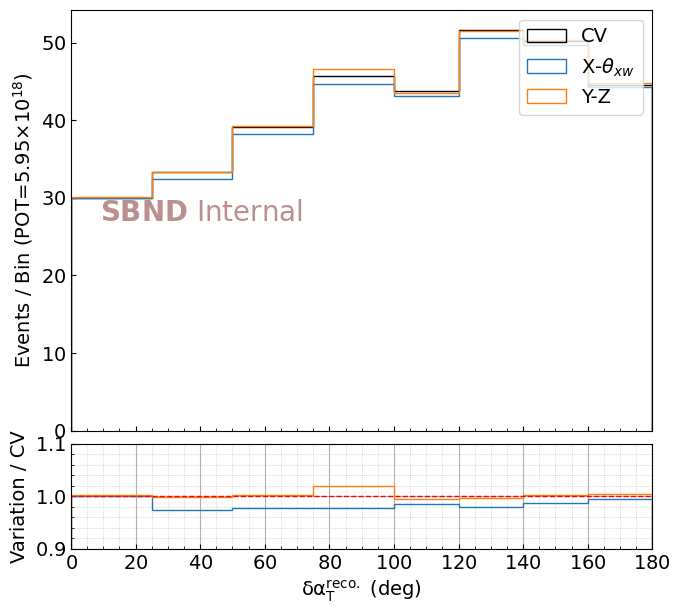

[338.36286888 333.02330293 339.35511442]


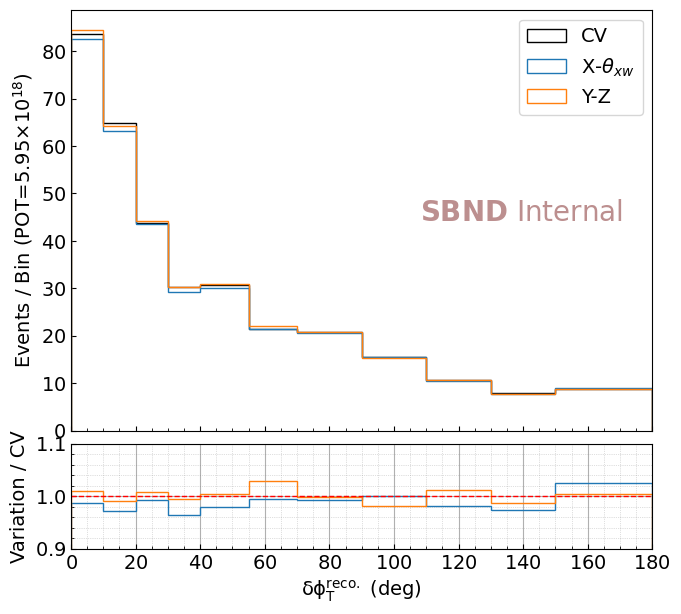

[338.36286888 333.02330293 339.35511442]


In [ ]:
for var_config in [VariableConfig.tki_del_Tp(), VariableConfig.tki_del_Tp_x(), VariableConfig.tki_del_Tp_y(), VariableConfig.tki_del_alpha(), VariableConfig.tki_del_phi()]:
        evtdfs = [syst_dfs[syst_key] for syst_key in syst_dfs.keys()]
        var_name = var_config.var_evt_reco_col
        bins = var_config.bins
        plot_labels = [var_config.var_labels[1], pot_label, ""]
        save_name = save_fig_dir + "/{}.png".format(var_config.var_save_name)
        n = detvar_plotter(evtdfs, 
                            var_name=var_name,
                            bins=bins,
                            plot_labels=plot_labels,
                            vline=[],
                            save_fig=save_fig, save_name=save_name)
        print(np.sum(n, axis=1))
        detvar_weights[var_config.var_save_name] = [n[i]/n[0] for i in range(len(syst_dfs.keys()))]

In [ ]:
# save to h5 file, use det var as the key
# note that these evtdfs have hdrdfs merged in

# save_filename = path.join(file_dir, "BNB_cosmics-sel_mup-{}.h5".format(this_variation))
# with pd.HDFStore(save_filename, "a") as store:
#     for syst_key in syst_dfs.keys():
#         print(syst_key)
#         store.put(syst_key, syst_dfs[syst_key])

# Detector Variation Systematic Uncertainty

In [ ]:
syst_name = "detvar"

In [ ]:
var_config = VariableConfig.muon_momentum()

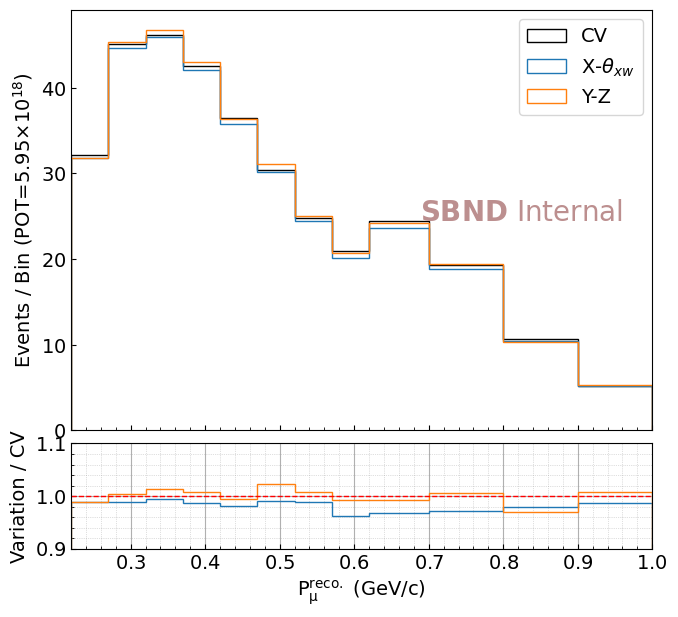

In [82]:
evtdfs = [syst_dfs[syst_key] for syst_key in syst_dfs.keys()]
var_name = var_config.var_evt_reco_col
bins = var_config.bins
plot_labels = [var_config.var_labels[1], pot_label, ""]
approval = "internal"
save_name = save_fig_dir + "/{}.png".format(var_config.var_save_name)
n = detvar_plotter(evtdfs, 
                    var_name=var_name,
                    bins=bins,
                    plot_labels=plot_labels,
                    approval=approval,
                    vline=[],
                    save_fig=save_fig, save_name=save_name)
detvar_weights[var_config.var_save_name] = [n[i]/n[0] for i in range(len(syst_dfs.keys()))]

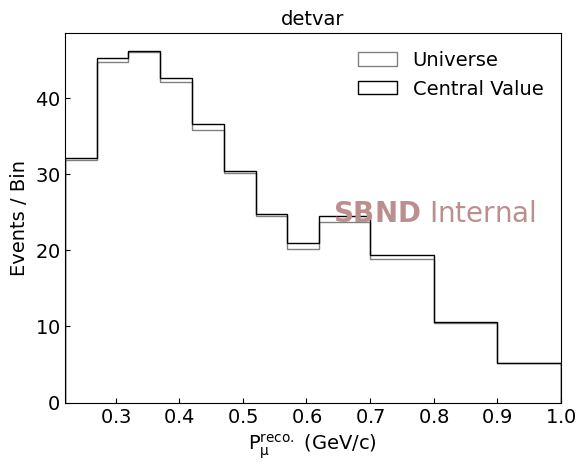

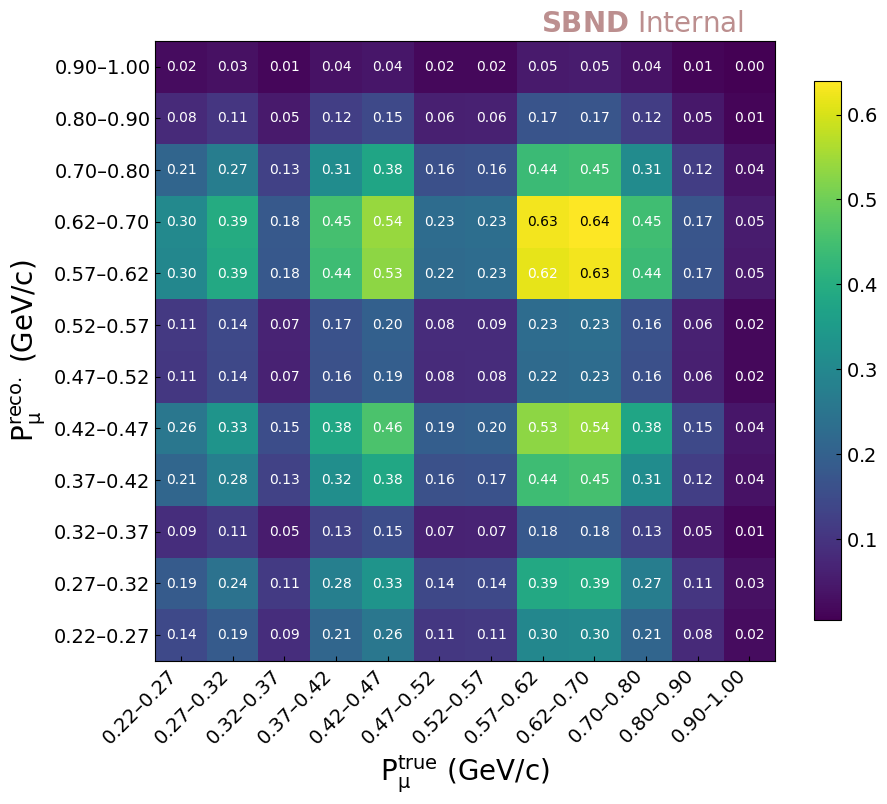

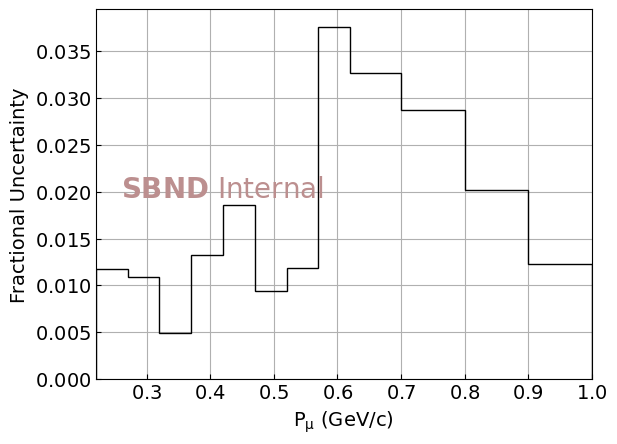

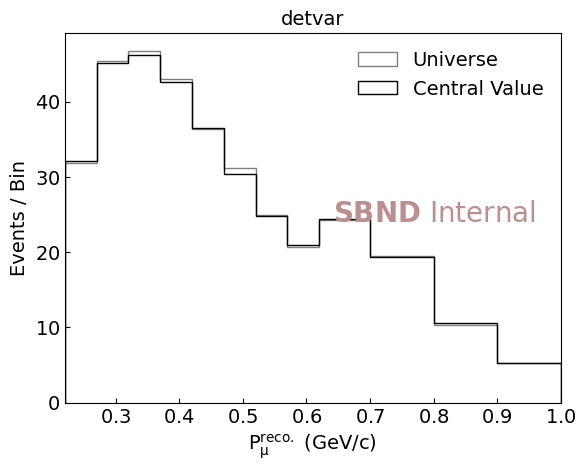

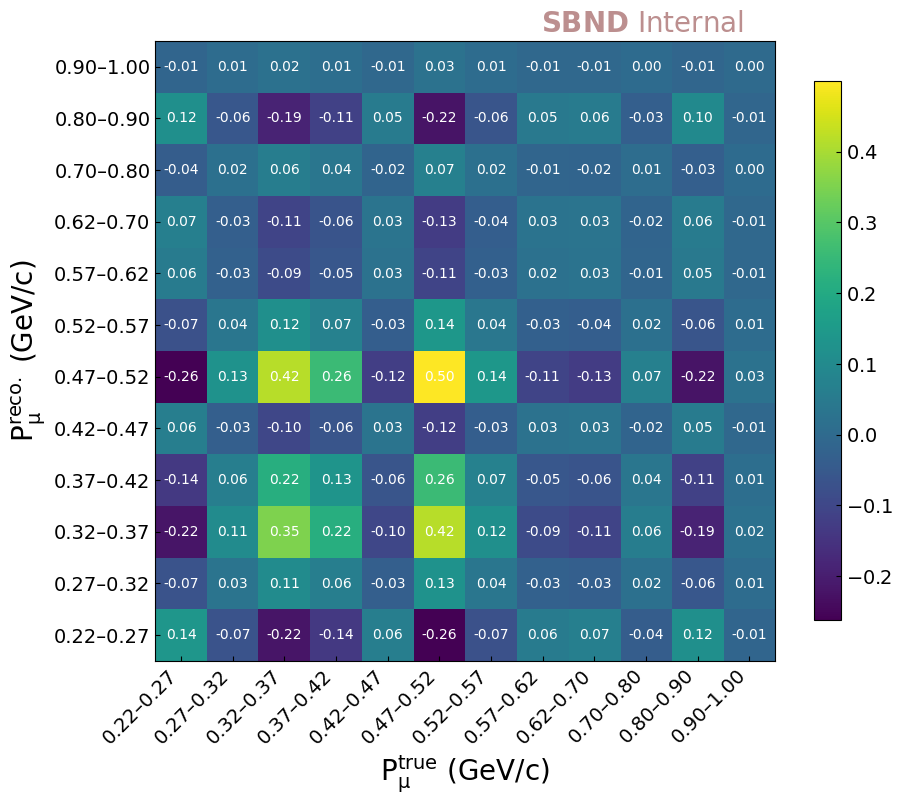

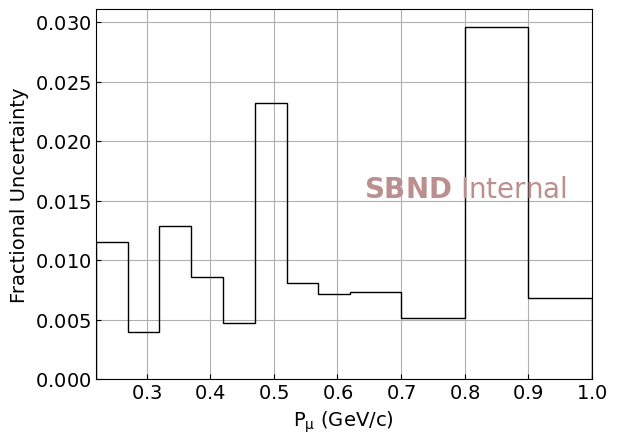

In [83]:
ret_dict = {}
for kidx, syst_key in enumerate(syst_dfs.keys()):
    if syst_key == "CV":
        continue

    # take syst variation as a unisim uncertainty
    cv_events = n[0]
    univ_events = np.array([n[kidx]]) 
    ret = get_covariance_matrix(univ_events, cv_events)
    ret_dict[syst_key] = ret
    plot_univ_hists(univ_events, 
                    cv_events,
                    syst_name, 
                    var_config)

    matrix_type = "cov"
    plot_labels = [var_config.var_labels[2], var_config.var_labels[1], ""]
    save_fig_name = "{}/{}-{}-{}.pdf".format(save_fig_dir, var_config.var_save_name, syst_name, matrix_type)
    title = "{} {}".format(syst_key, matrix_type)
    plot_heatmap(ret[matrix_type], 
                 bins=bins,
                 plot_labels=plot_labels,
                 save_fig=save_fig, 
                 save_name=save_fig_name)

    frac_unc = np.sqrt(np.diag(ret["cov_frac"]))
    plot_frac_unc(frac_unc, var_config)

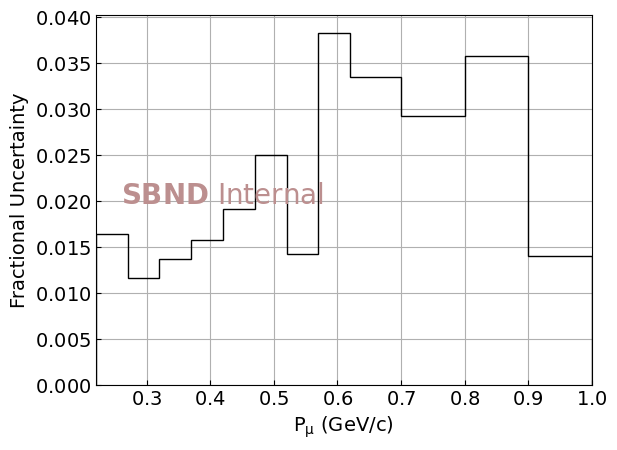

In [84]:
# get total detector variation covariance matrix
for kidx, syst_key in enumerate(ret_dict.keys()):
    if kidx == 0:
        detvar_total_cov = ret_dict[syst_key]["cov_frac"]
    else:
        detvar_total_cov += ret_dict[syst_key]["cov_frac"]

frac_unc = np.sqrt(np.diag(detvar_total_cov))
plot_frac_unc(frac_unc, var_config)

In [85]:
if 'syst_dict' not in locals():
    syst_dict = {}

syst_dict[var_config.var_save_name] = detvar_total_cov
for syst_key in ret_dict.keys():
    syst_dict[var_config.var_save_name + "_" + syst_key] = ret_dict[syst_key]["cov_frac"]

# save syst_dict as an npz file in the directory where dfs were loaded from
if save_result:
    print("saving syst_dict as npz in %s" % (file_dir))
    np.savez(file_dir + "/detvar_syst_dict.npz", **syst_dict)